<a href="https://colab.research.google.com/github/divyabharathikannappan/AH-PC/blob/main/src/SEED_V_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 SEED-V EDA — Adaptive Horizon Predictive Coding (AH-PC)
> **Author:** Divya Bharathi Kannappan &nbsp;|&nbsp; **Supervisor:** Naimul Khan

This notebook performs a complete Exploratory Data Analysis of the **SEED-V**
Differential Entropy (DE) feature dataset — the foundation of the AH-PC project.

**Sections:**
1. Mount Drive & Load Data
2. Dataset Summary & Descriptive Statistics
3. Class Distribution (Emotion Balance)
4. DE Feature Distributions (per Band & Channel)
5. Subject-to-Subject Variability
6. Trial-Level Temporal Patterns
7. Pair Structure — Past vs Future Segment Analysis
8. Inter-Channel Correlation (Topographic Patterns)
9. PCA / t-SNE Embedding of Latent Feature Space
10. Key Observations & AH-PC Implications

## 0. Install & Import

In [ ]:
# ── Installs (run once) ──────────────────────────────────────
# !pip install seaborn scikit-learn umap-learn -q  # uncomment if needed

import os, glob, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import defaultdict
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
EMOTION_NAMES  = ['Disgust', 'Fear', 'Sad', 'Neutral', 'Happy']
EMOTION_COLORS = ['#E07B54', '#7B68EE', '#5B9BD5', '#A9A9A9', '#70B87E']
BAND_NAMES     = ['Delta\n(0.5–4 Hz)', 'Theta\n(4–8 Hz)',
                  'Alpha\n(8–13 Hz)', 'Beta\n(13–30 Hz)', 'Gamma\n(30–45 Hz)']
BAND_COLORS    = ['#4E79A7', '#59A14F', '#F28E2B', '#E15759', '#76B7B2']
N_CHANNELS     = 62
N_BANDS        = 5
print('Imports complete')

Imports complete


## 1. Mount Drive & Load Data

Adjust `FOLDER_PATH` to point to your `.npz` files.
Each `.npz` contains a pickled dict `{trial_id: array}` for both `data` and `label`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

FOLDER_PATH = '/content/drive/MyDrive/MRP/EEG_DE_features'

npz_files = sorted(glob.glob(f'{FOLDER_PATH}/*.npz'))
print(f'Found {len(npz_files)} .npz files:')
for f in npz_files:
    print(f'  {os.path.basename(f)}')

Mounted at /content/drive
Found 16 .npz files:
  10_123.npz
  11_123.npz
  12_123.npz
  13_123.npz
  14_123.npz
  15_123.npz
  16_123.npz
  1_123.npz
  2_123.npz
  3_123.npz
  4_123.npz
  5_123.npz
  6_123.npz
  7_123.npz
  8_123.npz
  9_123.npz


In [ ]:
# ── Load ALL subjects ──────────────────────────────────────────
all_subjects = {}   # {subject_id: {'data': {...}, 'labels': {...}}}

for npz_path in npz_files:
    subject_id = int(os.path.basename(npz_path).split('_')[0])
    with np.load(npz_path, allow_pickle=True) as npz:
        raw_data   = pickle.loads(npz['data'].tobytes())
        raw_labels = pickle.loads(npz['label'].tobytes())
    all_subjects[subject_id] = {'data': raw_data, 'labels': raw_labels}

print(f'Loaded {len(all_subjects)} subjects.')
print(f'Subject IDs: {sorted(all_subjects.keys())}')

Loaded 16 subjects.
Subject IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


In [ ]:
# ── Build flat arrays for EDA ─────────────────────────────────
# Each entry: (subject_id, trial_id, segment_idx, emotion_label, DE_vector[310])

records = []
for sid, subj in all_subjects.items():
    for tid, flat_arr in subj['data'].items():
        segs   = flat_arr.reshape(-1, N_CHANNELS, N_BANDS)  # (T, 62, 5)
        labels = subj['labels'][tid]
        for i, (seg, lbl) in enumerate(zip(segs, labels)):
            records.append({
                'subject': sid,
                'trial':   tid,
                'seg_idx': i,
                'emotion': int(lbl),
                'de':      seg.copy()   # shape (62, 5)
            })

print(f'Total segments loaded: {len(records):,}')
print(f'Shape of one DE matrix: {records[0]["de"].shape}  (channels × bands)')

Total segments loaded: 29,168
Shape of one DE matrix: (62, 5)  (channels × bands)


## 2. Dataset Summary & Descriptive Statistics

High-level counts and per-subject breakdown.

In [ ]:
# ── Summary table ─────────────────────────────────────────────
summary_rows = []
for sid in sorted(all_subjects.keys()):
    subj_recs = [r for r in records if r['subject'] == sid]
    n_trials  = len(all_subjects[sid]['data'])
    n_segs    = len(subj_recs)
    label_counts = {e: sum(1 for r in subj_recs if r['emotion']==e) for e in range(5)}
    summary_rows.append({'Subject': sid, 'Trials': n_trials, 'Segments': n_segs,
                         **{f'{EMOTION_NAMES[e]}': label_counts[e] for e in range(5)}})

df_summary = pd.DataFrame(summary_rows).set_index('Subject')
print('=== Per-Subject Segment Counts ===')
print(df_summary.to_string())
print(f'\nTotal segments : {df_summary["Segments"].sum():,}')
print(f'Mean per subject: {df_summary["Segments"].mean():.1f}')
print(f'Std  per subject: {df_summary["Segments"].std():.1f}')

=== Per-Subject Segment Counts ===
         Trials  Segments  Disgust  Fear  Sad  Neutral  Happy
Subject                                                      
1            45      1823      306   373  476      367    301
2            45      1823      306   373  476      367    301
3            45      1823      306   373  476      367    301
4            45      1823      306   373  476      367    301
5            45      1823      306   373  476      367    301
6            45      1823      306   373  476      367    301
7            45      1823      306   373  476      367    301
8            45      1823      306   373  476      367    301
9            45      1823      306   373  476      367    301
10           45      1823      306   373  476      367    301
11           45      1823      306   373  476      367    301
12           45      1823      306   373  476      367    301
13           45      1823      306   373  476      367    301
14           45      1823      306 

In [ ]:
# ── Descriptive stats on DE values ────────────────────────────
all_de = np.stack([r['de'] for r in records])   # (N, 62, 5)
print(f'DE array shape : {all_de.shape}  (segments, channels, bands)')
print(f'\nGlobal DE statistics:')
print(f'  Mean   : {all_de.mean():.4f}')
print(f'  Std    : {all_de.std():.4f}')
print(f'  Min    : {all_de.min():.4f}')
print(f'  Max    : {all_de.max():.4f}')
print(f'  Median : {np.median(all_de):.4f}')
print(f'  Skew   : {stats.skew(all_de.flatten()):.4f}')
print(f'  Kurt   : {stats.kurtosis(all_de.flatten()):.4f}')
print('\nPer-band mean DE:')
for b, name in enumerate(['Delta','Theta','Alpha','Beta','Gamma']):
    print(f'  {name:6s}: mean={all_de[:,:,b].mean():.4f}  std={all_de[:,:,b].std():.4f}')

DE array shape : (29168, 62, 5)  (segments, channels, bands)

Global DE statistics:
  Mean   : 6.4042
  Std    : 2.2723
  Min    : -2.2462
  Max    : 23.5431
  Median : 6.6116
  Skew   : -0.3624
  Kurt   : 0.3918

Per-band mean DE:
  Delta : mean=8.5293  std=1.4663
  Theta : mean=7.2735  std=1.3718
  Alpha : mean=6.7362  std=1.5306
  Beta  : mean=5.4411  std=1.7341
  Gamma : mean=4.0411  std=2.1308


## 3. Class Distribution (Emotion Balance)

Checks whether the 5 emotion classes are balanced — important for
understanding whether class weighting is needed at fine-tuning time.

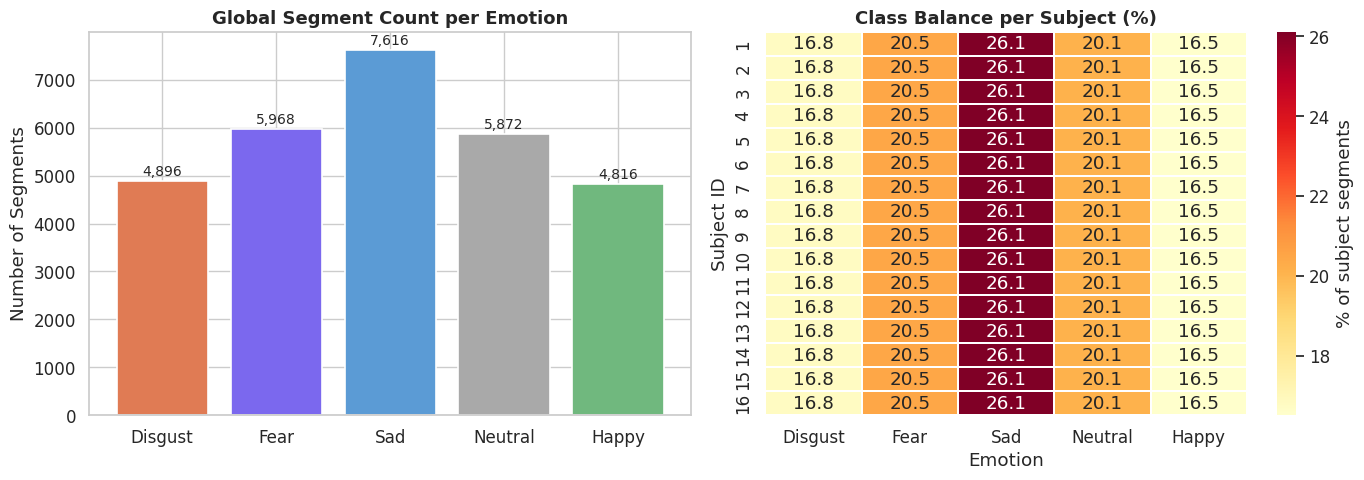

Class imbalance ratio (max/min): 1.58x


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Global class balance
all_labels  = [r['emotion'] for r in records]
label_counts = [all_labels.count(e) for e in range(5)]
bars = axes[0].bar(EMOTION_NAMES, label_counts, color=EMOTION_COLORS,
                   edgecolor='white', linewidth=1.2)
axes[0].set_title('Global Segment Count per Emotion', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Segments')
for bar, cnt in zip(bars, label_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{cnt:,}', ha='center', va='bottom', fontsize=10)

# Per-subject class balance heatmap
balance_mat = df_summary[[n for n in EMOTION_NAMES]].values.astype(float)
balance_pct = (balance_mat.T / balance_mat.sum(axis=1)).T * 100
sns.heatmap(balance_pct, ax=axes[1], annot=True, fmt='.1f',
            xticklabels=EMOTION_NAMES,
            yticklabels=df_summary.index,
            cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': '% of subject segments'})
axes[1].set_title('Class Balance per Subject (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Emotion'); axes[1].set_ylabel('Subject ID')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Class imbalance ratio (max/min): {max(label_counts)/min(label_counts):.2f}x')

## 4. DE Feature Distributions per Frequency Band

Differential Entropy values should increase from slow (Delta) to fast (Gamma) bands.
Deviations from this pattern by emotion reveal discriminative spectral signatures.

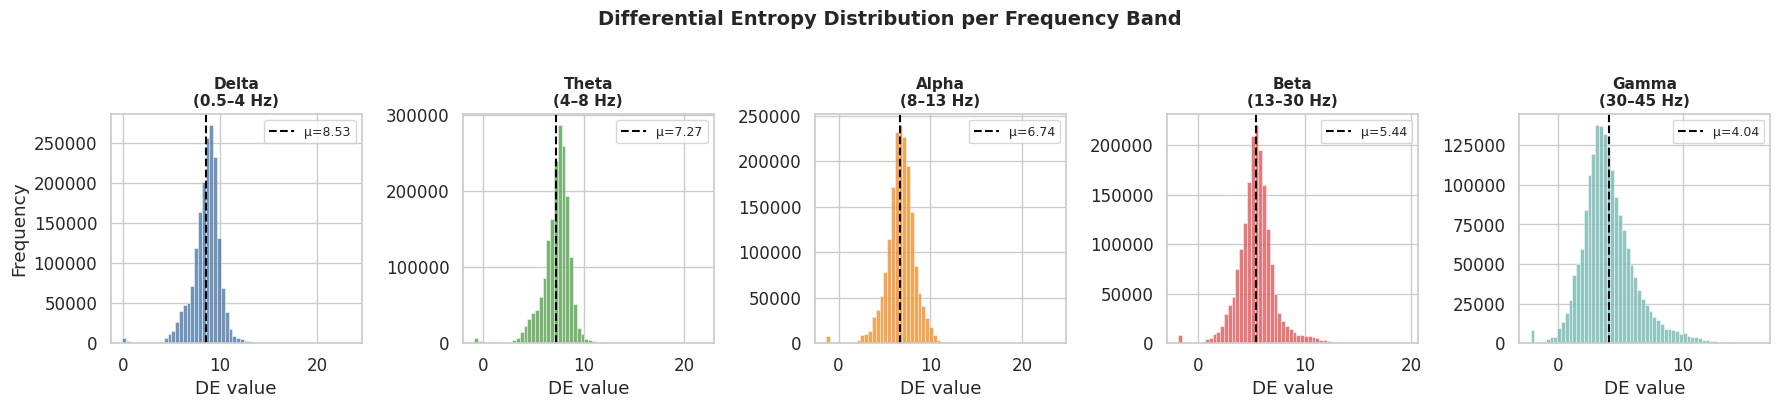

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)

for b, (ax, bname, bcol) in enumerate(zip(axes, BAND_NAMES, BAND_COLORS)):
    band_data = all_de[:, :, b].flatten()   # all channels, all segments
    ax.hist(band_data, bins=60, color=bcol, alpha=0.8, edgecolor='white', linewidth=0.4)
    ax.axvline(band_data.mean(), color='black', linewidth=1.5, linestyle='--', label=f'μ={band_data.mean():.2f}')
    ax.set_title(bname, fontsize=11, fontweight='bold')
    ax.set_xlabel('DE value')
    ax.legend(fontsize=9)
    if b == 0: ax.set_ylabel('Frequency')

plt.suptitle('Differential Entropy Distribution per Frequency Band', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('de_band_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

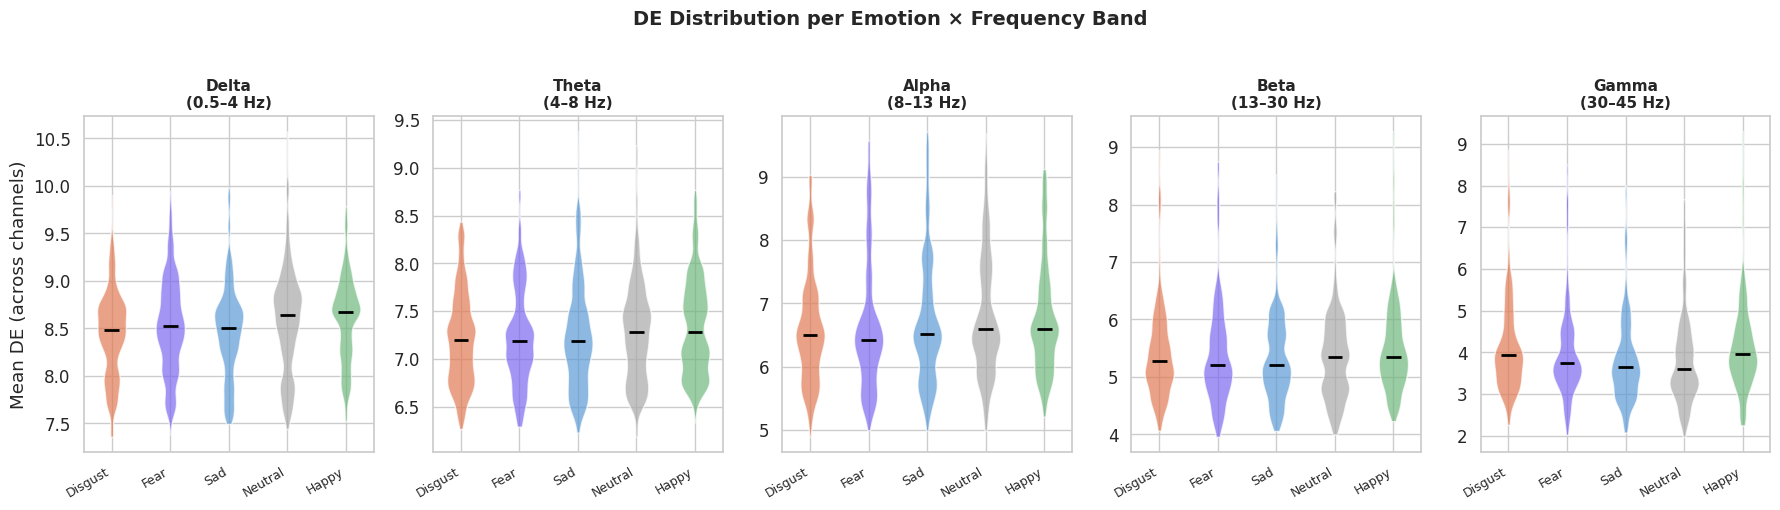

In [ ]:
# ── DE by emotion per band (violin plot) ──────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for b, (ax, bname, bcol) in enumerate(zip(axes, BAND_NAMES, BAND_COLORS)):
    # mean DE per segment for this band (avg across channels)
    emotion_de = {e: [] for e in range(5)}
    for r in records:
        emotion_de[r['emotion']].append(r['de'][:, b].mean())
    data_list = [emotion_de[e] for e in range(5)]

    vp = ax.violinplot(data_list, positions=range(5), showmedians=True, showextrema=False)
    for pc, col in zip(vp['bodies'], EMOTION_COLORS):
        pc.set_facecolor(col); pc.set_alpha(0.7)
    vp['cmedians'].set_color('black'); vp['cmedians'].set_linewidth(2)
    ax.set_xticks(range(5)); ax.set_xticklabels(EMOTION_NAMES, rotation=30, ha='right', fontsize=9)
    ax.set_title(bname, fontsize=11, fontweight='bold')
    if b == 0: ax.set_ylabel('Mean DE (across channels)')

plt.suptitle('DE Distribution per Emotion × Frequency Band', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('de_emotion_band_violin.png', dpi=150, bbox_inches='tight')
plt.show()

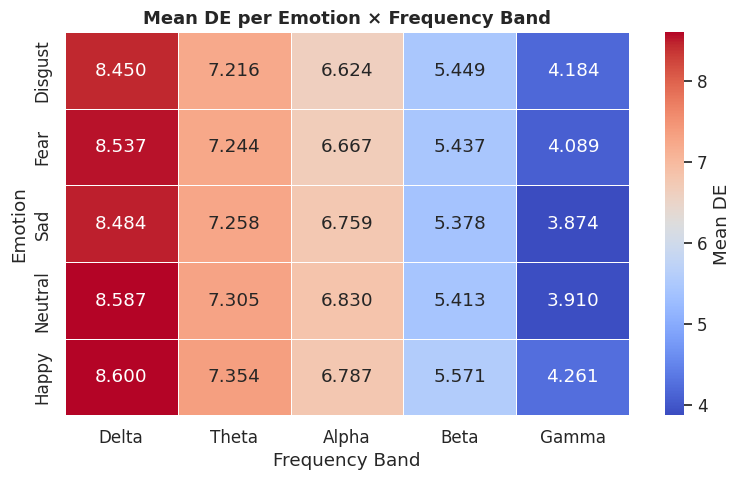

In [ ]:
# ── Mean DE heatmap: emotion × band ───────────────────────────
de_emotion_band = np.zeros((5, 5))   # emotions × bands
for e in range(5):
    segs_e = all_de[[r['emotion']==e for r in records]]
    de_emotion_band[e] = segs_e.mean(axis=(0, 1))  # mean over segs & channels

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(de_emotion_band, ax=ax,
            xticklabels=['Delta','Theta','Alpha','Beta','Gamma'],
            yticklabels=EMOTION_NAMES,
            annot=True, fmt='.3f', cmap='coolwarm', linewidths=0.5,
            cbar_kws={'label': 'Mean DE'})
ax.set_title('Mean DE per Emotion × Frequency Band', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequency Band'); ax.set_ylabel('Emotion')
plt.tight_layout()
plt.savefig('de_emotion_band_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Subject-to-Subject Variability

EEG is highly subject-dependent. This section quantifies how much the DE
distributions shift across subjects — critical for understanding why
subject-dependent pre-training was chosen in the baseline.

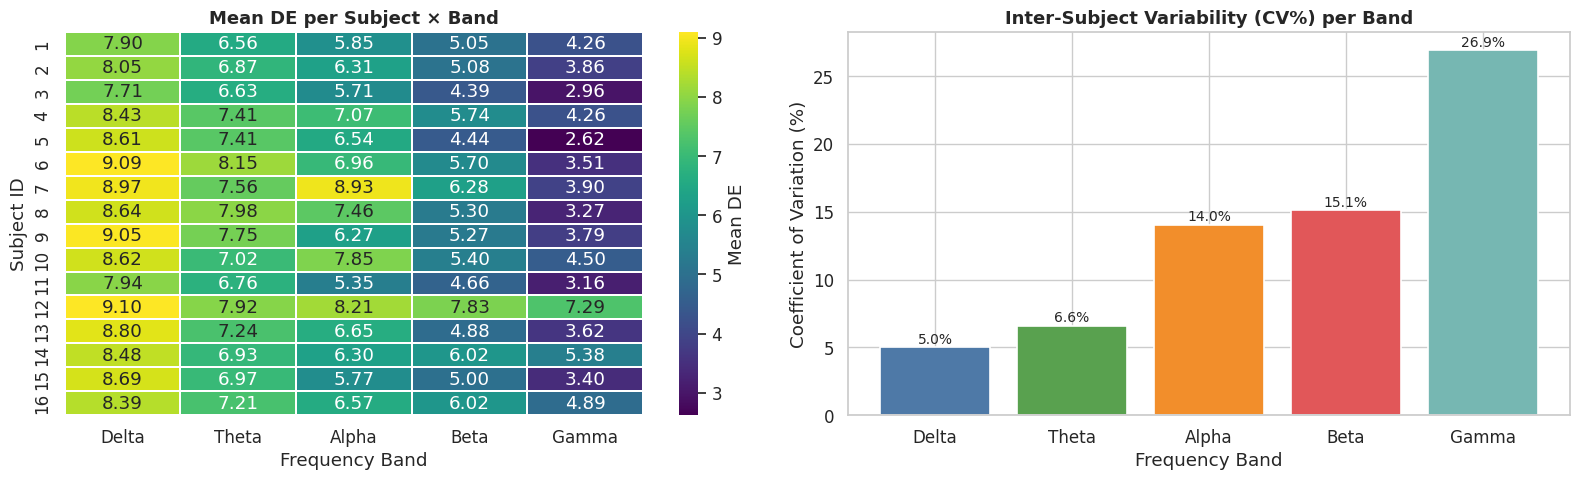

In [ ]:
# ── Mean DE per subject per band ─────────────────────────────
subj_ids = sorted(all_subjects.keys())
subj_band_mean = np.zeros((len(subj_ids), 5))  # subjects × bands
subj_band_std  = np.zeros((len(subj_ids), 5))

for i, sid in enumerate(subj_ids):
    segs_s = all_de[[r['subject']==sid for r in records]]
    subj_band_mean[i] = segs_s.mean(axis=(0, 1))
    subj_band_std[i]  = segs_s.std(axis=(0, 1))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap: subject × band mean
sns.heatmap(subj_band_mean, ax=axes[0],
            xticklabels=['Delta','Theta','Alpha','Beta','Gamma'],
            yticklabels=subj_ids,
            annot=True, fmt='.2f', cmap='viridis', linewidths=0.3,
            cbar_kws={'label': 'Mean DE'})
axes[0].set_title('Mean DE per Subject × Band', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency Band'); axes[0].set_ylabel('Subject ID')

# Coefficient of variation across subjects per band
cv_per_band = subj_band_mean.std(axis=0) / subj_band_mean.mean(axis=0) * 100
axes[1].bar(['Delta','Theta','Alpha','Beta','Gamma'], cv_per_band,
            color=BAND_COLORS, edgecolor='white', linewidth=1.2)
axes[1].set_title('Inter-Subject Variability (CV%) per Band', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Coefficient of Variation (%)')
axes[1].set_xlabel('Frequency Band')
for i, (v, col) in enumerate(zip(cv_per_band, BAND_COLORS)):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('subject_variability.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── ANOVA: is inter-subject variance significant? ─────────────
print('One-way ANOVA: are subject means significantly different per band?')
print('-' * 60)
for b, bname in enumerate(['Delta','Theta','Alpha','Beta','Gamma']):
    groups = [all_de[[r['subject']==sid for r in records], :, b].mean(axis=1)
              for sid in subj_ids]
    f_stat, p_val = stats.f_oneway(*groups)
    sig = '*** (p<0.001)' if p_val < 0.001 else ('** (p<0.01)' if p_val < 0.01 else '(n.s.)')
    print(f'  {bname:6s}:  F={f_stat:7.2f}  p={p_val:.2e}  {sig}')

One-way ANOVA: are subject means significantly different per band?
------------------------------------------------------------
  Delta :  F=4693.21  p=0.00e+00  *** (p<0.001)
  Theta :  F=6829.22  p=0.00e+00  *** (p<0.001)
  Alpha :  F=20326.31  p=0.00e+00  *** (p<0.001)
  Beta  :  F=11915.43  p=0.00e+00  *** (p<0.001)
  Gamma :  F=8231.07  p=0.00e+00  *** (p<0.001)


## 6. Trial-Level Temporal Patterns

Examines how DE evolves over time within a trial.
Stable signals (easy to predict far ahead) vs. volatile signals (hard to predict) —
this directly motivates the adaptive horizon mechanism in AH-PC.

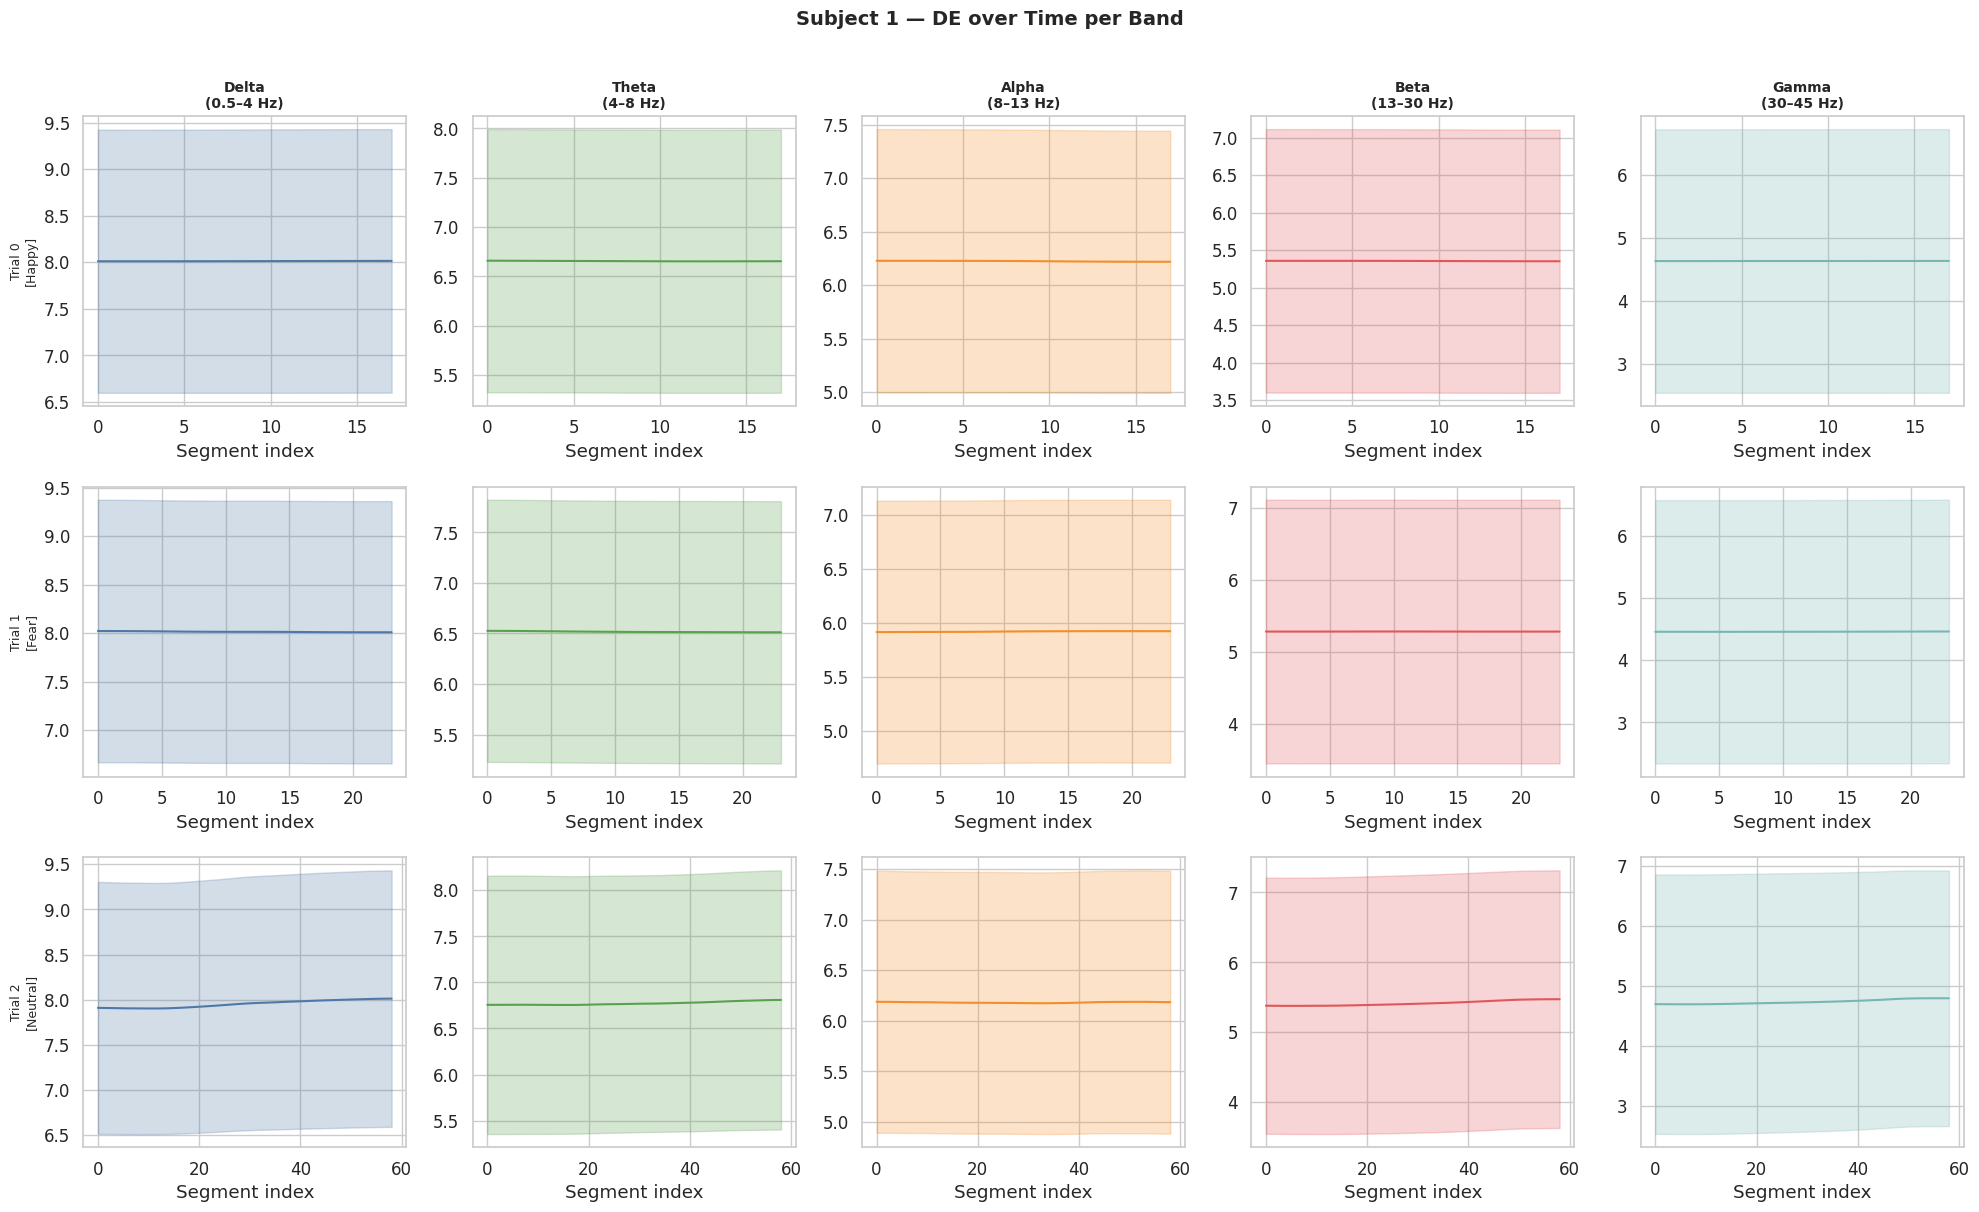

In [ ]:
# ── Plot DE over time for sample trials (one subject) ─────────
sample_sid = sorted(all_subjects.keys())[0]
sample_data = all_subjects[sample_sid]

sample_trials = list(sample_data['data'].keys())[:3]   # first 3 trials
fig, axes = plt.subplots(len(sample_trials), 5, figsize=(20, 4*len(sample_trials)))

for row, tid in enumerate(sample_trials):
    segs   = sample_data['data'][tid].reshape(-1, N_CHANNELS, N_BANDS)
    labels = sample_data['labels'][tid]
    t      = np.arange(len(segs))
    emotion_label = EMOTION_NAMES[int(labels[0])]

    for b, (ax, bname, bcol) in enumerate(zip(axes[row], BAND_NAMES, BAND_COLORS)):
        mean_de = segs[:, :, b].mean(axis=1)   # avg over channels
        std_de  = segs[:, :, b].std(axis=1)
        ax.plot(t, mean_de, color=bcol, linewidth=1.5)
        ax.fill_between(t, mean_de - std_de, mean_de + std_de,
                        alpha=0.25, color=bcol)
        if row == 0: ax.set_title(bname, fontsize=10, fontweight='bold')
        if b == 0: ax.set_ylabel(f'Trial {tid}\n[{emotion_label}]', fontsize=9)
        ax.set_xlabel('Segment index')

plt.suptitle(f'Subject {sample_sid} — DE over Time per Band',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

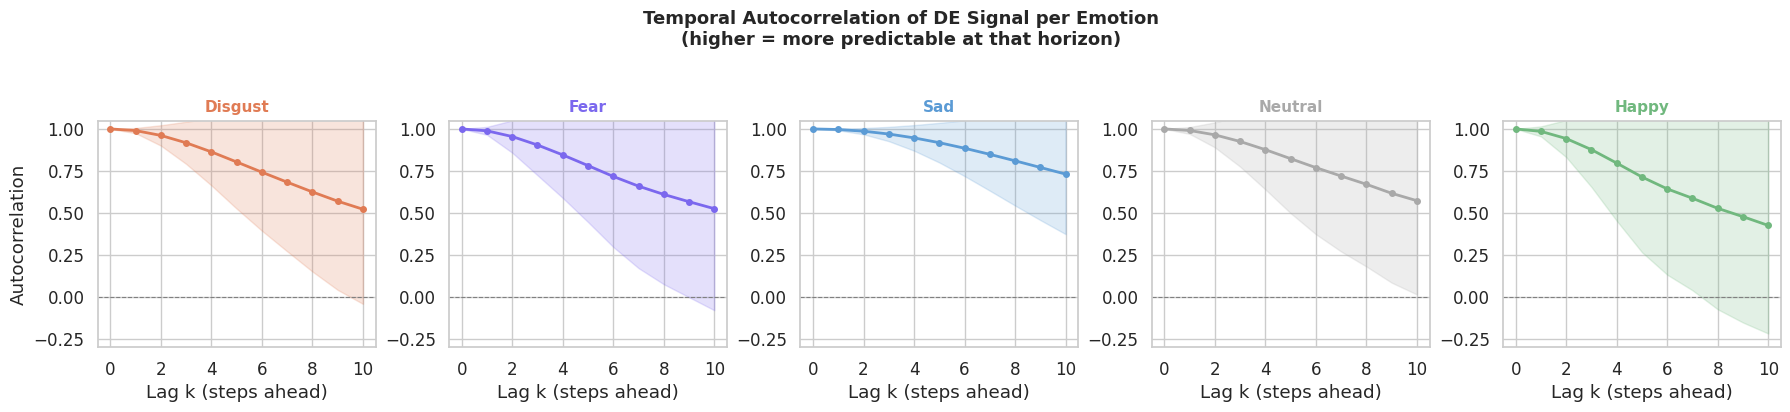

NOTE for AH-PC: emotions where autocorrelation drops quickly → model should prefer short horizons (small k). Slow-decaying autocorrelation → long horizons.


In [ ]:
# ── Temporal autocorrelation: how predictable is the signal? ──
# High autocorrelation at lag k → easy to predict k steps ahead
# This directly reveals which horizons matter for each emotion

MAX_LAG = 10
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for e, (ax, ename, ecol) in enumerate(zip(axes, EMOTION_NAMES, EMOTION_COLORS)):
    # Collect all trial DE sequences for this emotion
    autocorrs = []
    for sid, subj in all_subjects.items():
        for tid, flat_arr in subj['data'].items():
            segs   = flat_arr.reshape(-1, N_CHANNELS, N_BANDS)
            labels = subj['labels'][tid]
            if int(labels[0]) != e:
                continue
            # Mean DE across channels+bands for this trial
            ts = segs.mean(axis=(1, 2))   # shape: (T,)
            if len(ts) <= MAX_LAG:
                continue
            # Compute autocorrelation at each lag
            ac = [np.corrcoef(ts[:-lag], ts[lag:])[0,1] if lag > 0 else 1.0
                  for lag in range(MAX_LAG+1)]
            autocorrs.append(ac)
    if not autocorrs:
        continue
    autocorrs = np.array(autocorrs)   # (n_trials, MAX_LAG+1)
    mean_ac = autocorrs.mean(axis=0)
    std_ac  = autocorrs.std(axis=0)

    ax.plot(range(MAX_LAG+1), mean_ac, color=ecol, linewidth=2, marker='o', markersize=4)
    ax.fill_between(range(MAX_LAG+1), mean_ac-std_ac, mean_ac+std_ac,
                    alpha=0.2, color=ecol)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(ename, fontsize=11, fontweight='bold', color=ecol)
    ax.set_xlabel('Lag k (steps ahead)')
    ax.set_ylim(-0.3, 1.05)
    ax.set_xticks(range(0, MAX_LAG+1, 2))
    if e == 0: ax.set_ylabel('Autocorrelation')

plt.suptitle('Temporal Autocorrelation of DE Signal per Emotion\n(higher = more predictable at that horizon)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('temporal_autocorrelation.png', dpi=150, bbox_inches='tight')
plt.show()

print('NOTE for AH-PC: emotions where autocorrelation drops quickly → model should',
      'prefer short horizons (small k). Slow-decaying autocorrelation → long horizons.')

## 7. Pair Structure — Past vs Future Segment Analysis

The baseline (PC-SSL) always pairs segment[i] → segment[i+1].
AH-PC extends this to k ∈ {1, 2, 4, 8}.
Here we measure how similar consecutive segments are at each lag —
i.e., how hard the prediction task is at each horizon.

In [ ]:
# ── Cosine similarity between segment[i] and segment[i+k] ────
HORIZONS = [1, 2, 4, 8]
cos_sim_by_horizon = {k: [] for k in HORIZONS}
mse_by_horizon     = {k: [] for k in HORIZONS}

for sid, subj in all_subjects.items():
    for tid, flat_arr in subj['data'].items():
        segs = flat_arr.reshape(-1, N_CHANNELS, N_BANDS)   # (T, 62, 5)
        flat = segs.reshape(len(segs), -1)                  # (T, 310)
        for k in HORIZONS:
            if len(flat) <= k:
                continue
            past   = flat[:-k]                              # (T-k, 310)
            future = flat[k:]
            # Cosine similarity per pair
            norms  = (np.linalg.norm(past, axis=1, keepdims=True) *
                      np.linalg.norm(future, axis=1, keepdims=True))
            cos    = (past * future).sum(axis=1) / (norms.squeeze() + 1e-8)
            cos_sim_by_horizon[k].extend(cos.tolist())
            # MSE per pair
            mse = ((past - future)**2).mean(axis=1)
            mse_by_horizon[k].extend(mse.tolist())

print('Mean cosine similarity (past vs future) per horizon:')
for k in HORIZONS:
    cs = np.array(cos_sim_by_horizon[k])
    ms = np.array(mse_by_horizon[k])
    print(f'  k={k:2d}: cos_sim={cs.mean():.4f} ± {cs.std():.4f}   MSE={ms.mean():.4f} ± {ms.std():.4f}')

Mean cosine similarity (past vs future) per horizon:
  k= 1: cos_sim=1.0000 ± 0.0000   MSE=0.0000 ± 0.0000
  k= 2: cos_sim=1.0000 ± 0.0000   MSE=0.0000 ± 0.0001
  k= 4: cos_sim=1.0000 ± 0.0000   MSE=0.0001 ± 0.0003
  k= 8: cos_sim=1.0000 ± 0.0000   MSE=0.0005 ± 0.0011


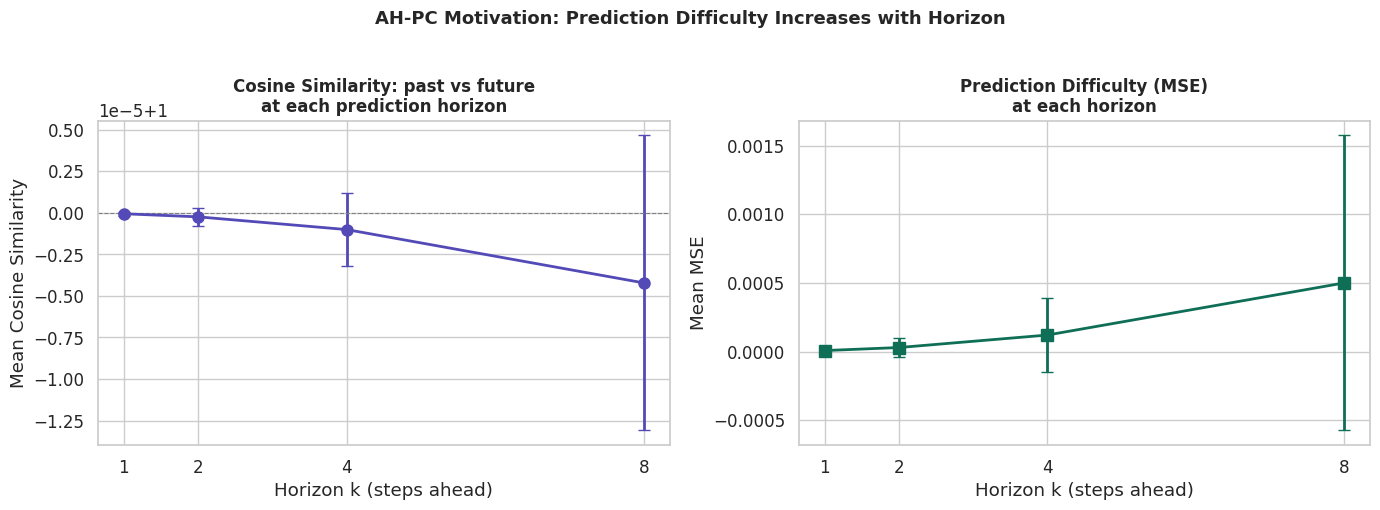

In [ ]:
# ── Visualise: how similarity drops with horizon ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cosine similarity
means_cos = [np.mean(cos_sim_by_horizon[k]) for k in HORIZONS]
stds_cos  = [np.std(cos_sim_by_horizon[k])  for k in HORIZONS]
axes[0].errorbar(HORIZONS, means_cos, yerr=stds_cos,
                 marker='o', linewidth=2, markersize=8, color='#534AB7', capsize=4)
axes[0].set_title('Cosine Similarity: past vs future\nat each prediction horizon', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Horizon k (steps ahead)')
axes[0].set_ylabel('Mean Cosine Similarity')
axes[0].set_xticks(HORIZONS)
axes[0].axhline(1.0, color='gray', linestyle='--', linewidth=0.8)

# MSE
means_mse = [np.mean(mse_by_horizon[k]) for k in HORIZONS]
stds_mse  = [np.std(mse_by_horizon[k])  for k in HORIZONS]
axes[1].errorbar(HORIZONS, means_mse, yerr=stds_mse,
                 marker='s', linewidth=2, markersize=8, color='#0F6E56', capsize=4)
axes[1].set_title('Prediction Difficulty (MSE)\nat each horizon', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Horizon k (steps ahead)')
axes[1].set_ylabel('Mean MSE')
axes[1].set_xticks(HORIZONS)

plt.suptitle('AH-PC Motivation: Prediction Difficulty Increases with Horizon',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pair_structure.png', dpi=150, bbox_inches='tight')
plt.show()

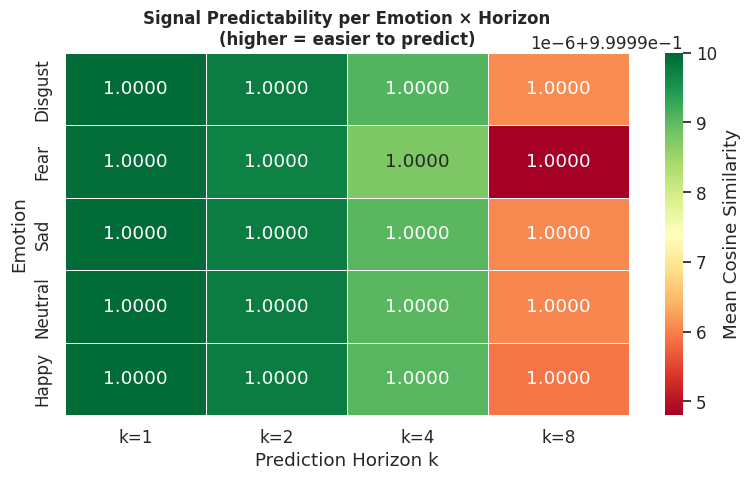

NOTE: emotions with fast similarity drop → AH-PC should learn high α for small k


In [ ]:
# ── Similarity per horizon × emotion ──────────────────────────
cos_sim_emotion_horizon = {e: {k: [] for k in HORIZONS} for e in range(5)}

for sid, subj in all_subjects.items():
    for tid, flat_arr in subj['data'].items():
        segs   = flat_arr.reshape(-1, N_CHANNELS, N_BANDS)
        labels = subj['labels'][tid]
        flat   = segs.reshape(len(segs), -1)
        emotion = int(labels[0])      # trial-level label
        for k in HORIZONS:
            if len(flat) <= k:
                continue
            past, future = flat[:-k], flat[k:]
            norms = (np.linalg.norm(past, axis=1, keepdims=True) *
                     np.linalg.norm(future, axis=1, keepdims=True))
            cos = (past * future).sum(axis=1) / (norms.squeeze() + 1e-8)
            cos_sim_emotion_horizon[emotion][k].extend(cos.tolist())

# Build matrix: rows=emotion, cols=horizon
mat = np.array([[np.mean(cos_sim_emotion_horizon[e][k]) for k in HORIZONS]
                for e in range(5)])

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(mat, ax=ax,
            xticklabels=[f'k={k}' for k in HORIZONS],
            yticklabels=EMOTION_NAMES,
            annot=True, fmt='.4f', cmap='RdYlGn',
            linewidths=0.5, vmin=mat.min(), vmax=1.0,
            cbar_kws={'label': 'Mean Cosine Similarity'})
ax.set_title('Signal Predictability per Emotion × Horizon\n(higher = easier to predict)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Prediction Horizon k'); ax.set_ylabel('Emotion')
plt.tight_layout()
plt.savefig('predictability_emotion_horizon.png', dpi=150, bbox_inches='tight')
plt.show()
print('NOTE: emotions with fast similarity drop → AH-PC should learn high α for small k')

## 8. Inter-Channel Correlation (Topographic Patterns)

Examines which electrode pairs are correlated, and whether correlation
patterns differ across emotions — motivation for the Channel Attention module.

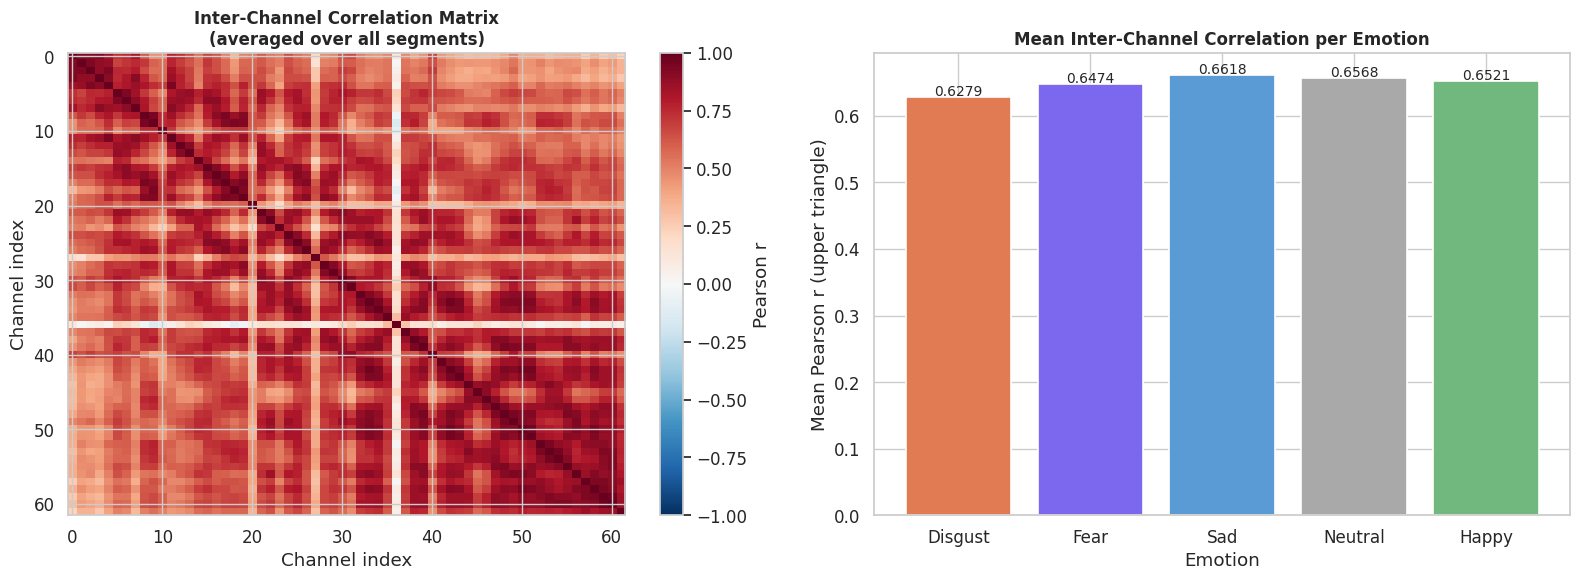

In [ ]:
# ── Average correlation matrix across all segments & subjects ─
# Using mean DE per channel (averaged over bands) per segment
mean_de_per_ch = all_de.mean(axis=2)   # (N_segs, 62)

corr_matrix = np.corrcoef(mean_de_per_ch.T)   # (62, 62)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full correlation matrix
im = axes[0].imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
axes[0].set_title('Inter-Channel Correlation Matrix\n(averaged over all segments)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Channel index'); axes[0].set_ylabel('Channel index')
plt.colorbar(im, ax=axes[0], label='Pearson r')

# Correlation by emotion — compute per-emotion mean correlation
emotion_corr = []
for e in range(5):
    mask = np.array([r['emotion']==e for r in records])
    de_e = mean_de_per_ch[mask]
    corr_e = np.corrcoef(de_e.T)
    emotion_corr.append(corr_e[np.triu_indices(N_CHANNELS, k=1)].mean())

axes[1].bar(EMOTION_NAMES, emotion_corr, color=EMOTION_COLORS,
            edgecolor='white', linewidth=1.2)
axes[1].set_title('Mean Inter-Channel Correlation per Emotion',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean Pearson r (upper triangle)')
axes[1].set_xlabel('Emotion')
for i, (v, col) in enumerate(zip(emotion_corr, EMOTION_COLORS)):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('channel_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. PCA and t-SNE Embedding of the Feature Space

Visualises whether raw DE features already form separable clusters
by emotion — sets the baseline separability that SSL pre-training aims to improve.

In [ ]:
# ── Prepare flattened feature matrix ─────────────────────────
# Subsample if large (for speed); use all if manageable
N_MAX = 5000
all_flat  = all_de.reshape(len(all_de), -1)   # (N, 310)
all_lbls  = np.array([r['emotion'] for r in records])
all_subjs = np.array([r['subject'] for r in records])

if len(all_flat) > N_MAX:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(all_flat), N_MAX, replace=False)
    X, y, s = all_flat[idx], all_lbls[idx], all_subjs[idx]
else:
    X, y, s = all_flat, all_lbls, all_subjs

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'Feature matrix for visualisation: {X_scaled.shape}')

Feature matrix for visualisation: (5000, 310)


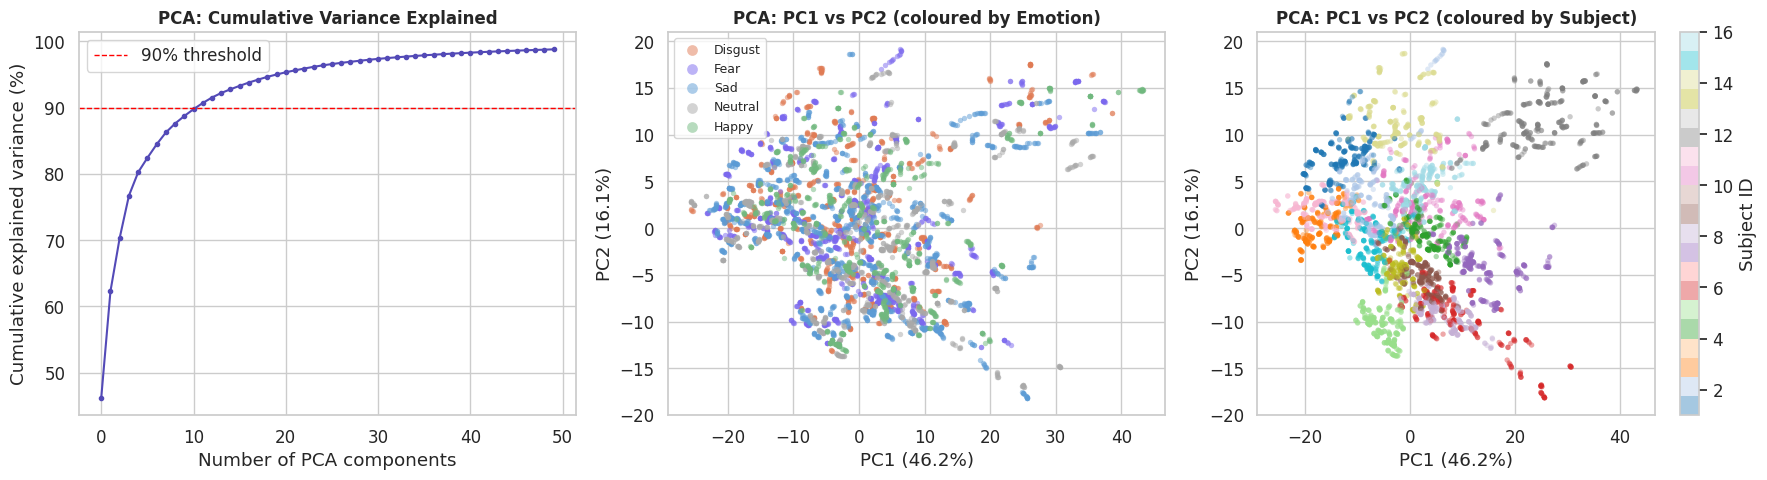

Components to explain 90% variance: 12


In [ ]:
# ── PCA ───────────────────────────────────────────────────────
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Variance explained
axes[0].plot(np.cumsum(pca.explained_variance_ratio_) * 100,
             marker='o', markersize=3, color='#534AB7', linewidth=1.5)
axes[0].axhline(90, color='red', linestyle='--', linewidth=1, label='90% threshold')
axes[0].set_xlabel('Number of PCA components')
axes[0].set_ylabel('Cumulative explained variance (%)')
axes[0].set_title('PCA: Cumulative Variance Explained', fontsize=12, fontweight='bold')
axes[0].legend()

# PC1 vs PC2 coloured by emotion
for e in range(5):
    mask = y == e
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=EMOTION_COLORS[e], label=EMOTION_NAMES[e],
                    alpha=0.5, s=15, linewidths=0)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA: PC1 vs PC2 (coloured by Emotion)', fontsize=12, fontweight='bold')
axes[1].legend(markerscale=2, fontsize=9)

# PC1 vs PC2 coloured by subject
sc = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=s,
                     cmap='tab20', alpha=0.4, s=15, linewidths=0)
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[2].set_title('PCA: PC1 vs PC2 (coloured by Subject)', fontsize=12, fontweight='bold')
plt.colorbar(sc, ax=axes[2], label='Subject ID')

plt.tight_layout()
plt.savefig('pca_embedding.png', dpi=150, bbox_inches='tight')
plt.show()

n90 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.90) + 1
print(f'Components to explain 90% variance: {n90}')

Running t-SNE... (may take ~1-2 min)


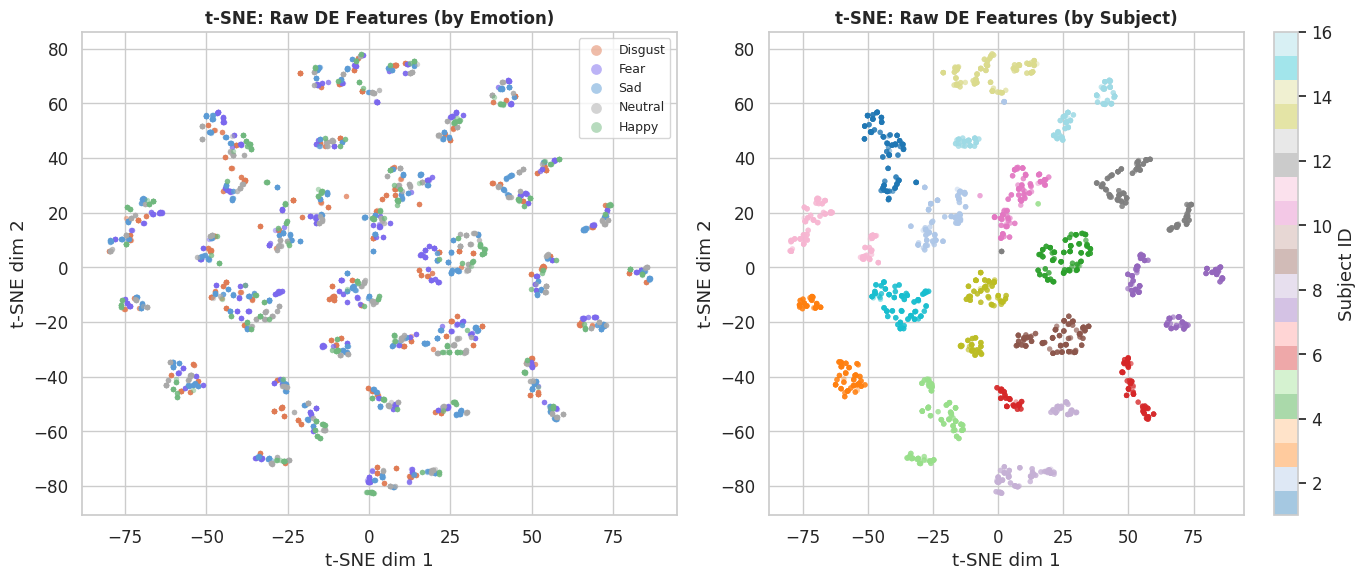

If subject clusters are tighter than emotion clusters → justifies subject-dependent pre-training


In [ ]:
# ── t-SNE (on PCA-reduced data for speed) ─────────────────────
print('Running t-SNE... (may take ~1-2 min)')
tsne = TSNE(n_components=2, perplexity=40, n_iter=1000,
            random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_pca[:, :20])   # use top-20 PCs

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for e in range(5):
    mask = y == e
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                    c=EMOTION_COLORS[e], label=EMOTION_NAMES[e],
                    alpha=0.5, s=15, linewidths=0)
axes[0].set_title('t-SNE: Raw DE Features (by Emotion)', fontsize=12, fontweight='bold')
axes[0].legend(markerscale=2, fontsize=9)
axes[0].set_xlabel('t-SNE dim 1'); axes[0].set_ylabel('t-SNE dim 2')

sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=s,
                      cmap='tab20', alpha=0.4, s=15, linewidths=0)
axes[1].set_title('t-SNE: Raw DE Features (by Subject)', fontsize=12, fontweight='bold')
plt.colorbar(sc2, ax=axes[1], label='Subject ID')
axes[1].set_xlabel('t-SNE dim 1'); axes[1].set_ylabel('t-SNE dim 2')

plt.tight_layout()
plt.savefig('tsne_embedding.png', dpi=150, bbox_inches='tight')
plt.show()
print('If subject clusters are tighter than emotion clusters → justifies subject-dependent pre-training')

## 10. Key Observations & AH-PC Implications

Summary of EDA findings and how each directly motivates AH-PC design choices.

In [ ]:
print('''
═══════════════════════════════════════════════════════════════════
  SEED-V EDA — KEY OBSERVATIONS
═══════════════════════════════════════════════════════════════════

1. CLASS BALANCE
   → Check plot section 3. If imbalanced (>1.5x ratio), use
     weighted CrossEntropyLoss at fine-tuning time.

2. DE INCREASES FROM DELTA → GAMMA
   → Confirms DE captures signal complexity correctly.
     Band attention in the encoder has meaningful gradients to learn.

3. EMOTION-BAND SIGNATURES EXIST
   → The DE heatmap (emotion × band) shows measurable differences.
     SSL pre-training should preserve — and amplify — these patterns.

4. HIGH INTER-SUBJECT VARIABILITY
   → ANOVA p-values confirm subjects differ significantly per band.
     Justifies subject-dependent pre-training in the baseline.
     AH-PC cross-domain goal requires addressing this at fine-tune time.

5. TEMPORAL AUTOCORRELATION VARIES BY EMOTION
   → Emotions with slow AC decay (e.g. Neutral) are predictable
     at longer horizons → AH-PC should assign high α to large k.
   → Emotions with fast AC decay (e.g. Fear) are harder to predict
     far ahead → AH-PC should assign high α to small k.
   → This is the empirical evidence that adaptive horizons are NEEDED.

6. PREDICTION DIFFICULTY GROWS WITH HORIZON (k=1,2,4,8)
   → Cosine similarity drops and MSE rises with k.
   → Different emotions have different slopes → AH-PC must learn
     these slopes and weight them via the Horizon Attention Module.

7. PCA/t-SNE SHOWS SUBJECT EFFECT DOMINATES EMOTION EFFECT
   → Raw DE features cluster more by subject than by emotion.
   → This is EXACTLY why SSL pre-training matters: it should learn
     representations where emotion clusters, not subject noise.
═══════════════════════════════════════════════════════════════════
''')


═══════════════════════════════════════════════════════════════════
  SEED-V EDA — KEY OBSERVATIONS
═══════════════════════════════════════════════════════════════════

1. CLASS BALANCE
   → Check plot section 3. If imbalanced (>1.5x ratio), use
     weighted CrossEntropyLoss at fine-tuning time.

2. DE INCREASES FROM DELTA → GAMMA
   → Confirms DE captures signal complexity correctly.
     Band attention in the encoder has meaningful gradients to learn.

3. EMOTION-BAND SIGNATURES EXIST
   → The DE heatmap (emotion × band) shows measurable differences.
     SSL pre-training should preserve — and amplify — these patterns.

4. HIGH INTER-SUBJECT VARIABILITY
   → ANOVA p-values confirm subjects differ significantly per band.
     Justifies subject-dependent pre-training in the baseline.
     AH-PC cross-domain goal requires addressing this at fine-tune time.

5. TEMPORAL AUTOCORRELATION VARIES BY EMOTION
   → Emotions with slow AC decay (e.g. Neutral) are predictable
     at longer hori